In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

z_dim = 100
num_classes = 10
batch_size = 64
lr = 2e-4
epochs = 10

# ================= DATA =================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root="./data", transform=transform, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


label_emb = nn.Embedding(num_classes, num_classes).to(device)


def build_generator():
    return nn.Sequential(
        nn.Linear(z_dim + num_classes, 256),
        nn.ReLU(True),
        nn.Linear(256, 7*7*128),
        nn.ReLU(True),
        nn.Unflatten(1, (128,7,7)),

        nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 7→14
        nn.BatchNorm2d(64),
        nn.ReLU(True),

        nn.ConvTranspose2d(64, 1, 4, 2, 1),   # 14→28
        nn.Tanh()
    ).to(device)


def build_discriminator():
    return nn.Sequential(
        nn.Conv2d(1 + num_classes, 64, 4, 2, 1),  # 28→14
        nn.LeakyReLU(0.2),

        nn.Conv2d(64, 128, 4, 2, 1),              # 14→7
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2),

        nn.Flatten(),
        nn.Linear(7*7*128, 1),
        nn.Sigmoid()
    ).to(device)

G = build_generator()
D = build_discriminator()

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

loss_fn = nn.BCELoss()


for epoch in range(epochs):
    for real, labels in loader:

        real = real.to(device)
        labels = labels.to(device)
        B = real.size(0)

        label_map = label_emb(labels).unsqueeze(2).unsqueeze(3)
        label_map = label_map.expand(-1, -1, 28, 28)

        # ===== TRAIN D =====
        noise = torch.randn(B, z_dim).to(device)
        fake_labels = torch.randint(0, num_classes, (B,)).to(device)
        fake_emb = label_emb(fake_labels)

        fake = G(torch.cat([noise, fake_emb], dim=1))

        fake_map = label_emb(fake_labels).unsqueeze(2).unsqueeze(3)
        fake_map = fake_map.expand(-1, -1, 28, 28)

        D_real = D(torch.cat([real, label_map], dim=1)).view(-1)
        D_fake = D(torch.cat([fake.detach(), fake_map], dim=1)).view(-1)

        loss_D = (loss_fn(D_real, torch.ones_like(D_real)) +
                  loss_fn(D_fake, torch.zeros_like(D_fake))) / 2

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()


        noise = torch.randn(B, z_dim).to(device)
        gen_labels = torch.randint(0, num_classes, (B,)).to(device)
        gen_emb = label_emb(gen_labels)

        fake = G(torch.cat([noise, gen_emb], dim=1))

        fake_map = label_emb(gen_labels).unsqueeze(2).unsqueeze(3)
        fake_map = fake_map.expand(-1, -1, 28, 28)

        output = D(torch.cat([fake, fake_map], dim=1)).view(-1)

        loss_G = loss_fn(output, torch.ones_like(output))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}: D={loss_D:.3f}, G={loss_G:.3f}")


def generate_digit(digit, n=5):
    labels = torch.tensor([digit]*n).to(device)
    emb = label_emb(labels)

    noise = torch.randn(n, z_dim).to(device)
    fake = G(torch.cat([noise, emb], dim=1))

    return fake



Epoch 1: D=0.630, G=2.484
Epoch 2: D=0.391, G=2.350
Epoch 3: D=0.412, G=2.004
Epoch 4: D=0.307, G=1.077
Epoch 5: D=0.343, G=0.447
Epoch 6: D=1.020, G=0.816
Epoch 7: D=0.633, G=1.139
Epoch 8: D=0.652, G=1.156
Epoch 9: D=0.630, G=1.418
Epoch 10: D=0.572, G=0.971


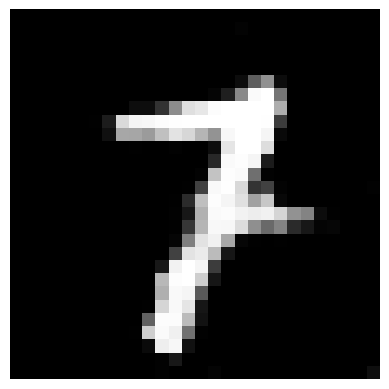

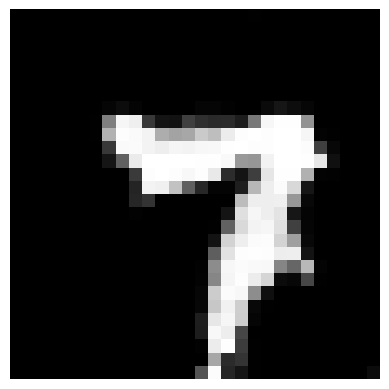

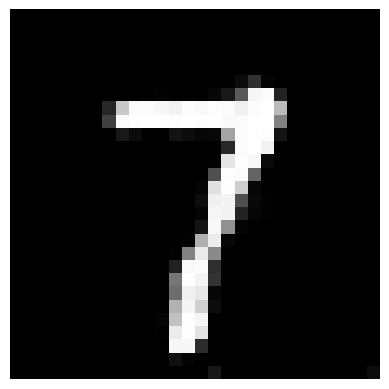

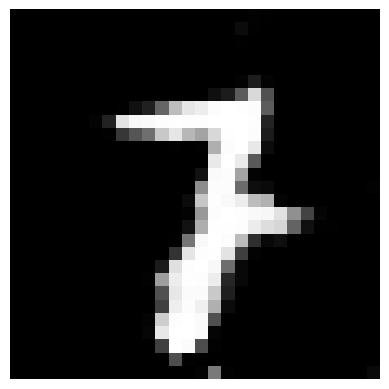

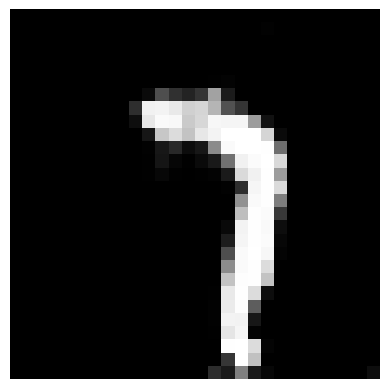

In [10]:
import matplotlib.pyplot as plt

samples = generate_digit(7, n=5)

for i in range(5):
    img = samples[i][0].detach().cpu()
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()